# Clase 3 · Análisis exploratorio de datos II

**Módulo 1: Introducción y fundamentos estadísticos** · Diplomado en Ciencia de Datos Aplicada · UTFSM

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daniopitz/diplomado-cdd/blob/main/03_eda_bivariado_colab.ipynb)

Versión para **Google Colab**. Antes de trabajar, guarde su propia copia con `Archivo > Guardar una copia en Drive`.

Objetivos de la sesión: analizar relaciones entre pares de variables (correlación, grupos y tablas de contingencia), ajustar una primera regresión y graficar con buenas prácticas.

## 1. Preparación

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# Gráficos más nítidos en pantallas de alta resolución
%config InlineBackend.figure_format = "retina"


In [2]:
BASE = (
    "https://raw.githubusercontent.com/daniopitz/diplomado-cdd/"
    "main/datos/eod_stgo/"
)
# Alternativa sin URL: suba eod_stgo.zip, descomprima y use la ruta local:
# !unzip -q eod_stgo.zip -d .
# BASE = "eod_stgo/"

In [3]:
viajes = pd.read_csv(BASE + "viajes.csv", sep=";", decimal=",", low_memory=False)
viajes.shape

(113591, 35)

In [4]:
hogares = pd.read_csv(BASE + "Hogares.csv", sep=";", decimal=",", low_memory=False)
hogares.shape

(18264, 21)

Hoy usamos también la tabla de **personas**: una fila por persona encuestada, con su sexo, edad y ocupación.

In [5]:
personas = pd.read_csv(BASE + "personas.csv", sep=";", decimal=",", low_memory=False)
personas.shape

(60054, 39)

In [6]:
from sklearn.datasets import load_iris

iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
nombres = {0: "setosa", 1: "versicolor", 2: "virginica"}
iris_df["species"] = pd.Series(iris.target).map(nombres)
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 2. Los conceptos, con iris

### El gráfico de dispersión

La clase pasada describimos variables de a una; hoy las cruzamos de a dos. Para dos cuantitativas, el gráfico es la **dispersión** (scatter): cada punto es una fila, y sus coordenadas son los valores de las dos variables.

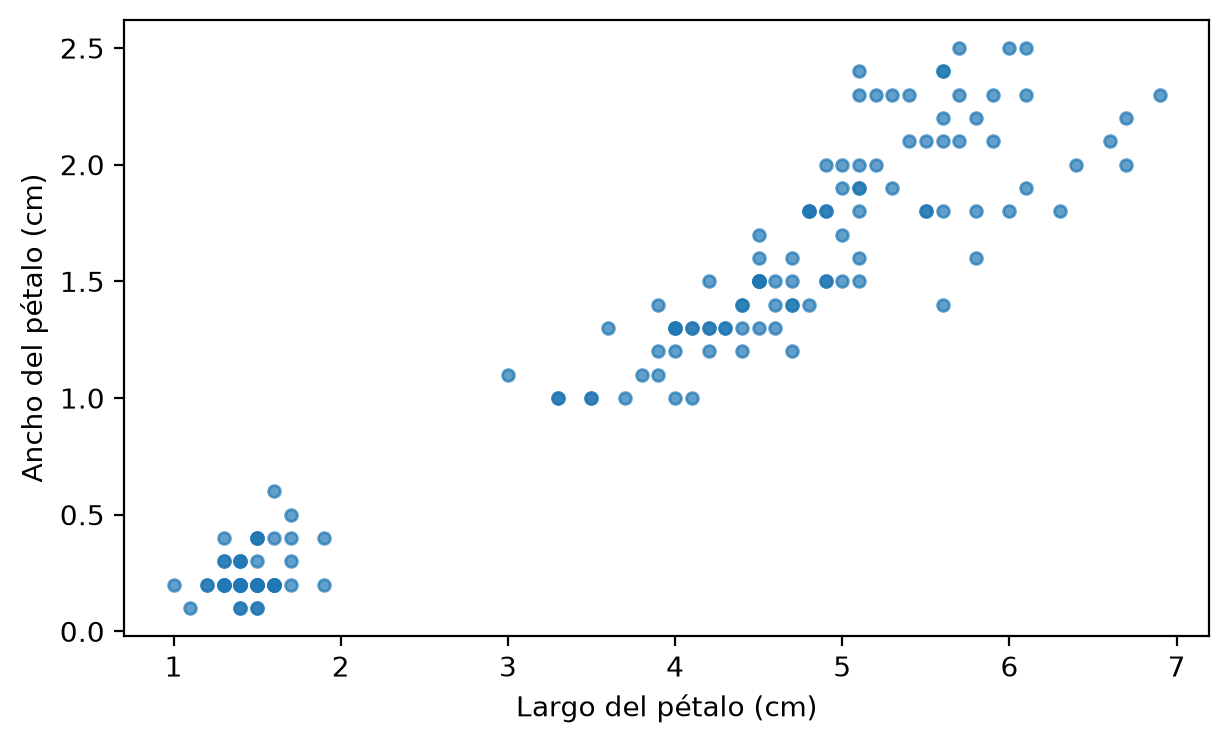

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(iris_df["petal length (cm)"], iris_df["petal width (cm)"],
           s=18, alpha=0.7)
ax.set_xlabel("Largo del pétalo (cm)")
ax.set_ylabel("Ancho del pétalo (cm)")
plt.show()

La nube sube en diagonal: pétalos más largos vienen con pétalos más anchos.

### La correlación

La **correlación de Pearson** resume esa relación en un número entre −1 y 1: fuerza y signo de la relación lineal. En Pandas es un método de la columna:

In [8]:
iris_df["petal length (cm)"].corr(iris_df["petal width (cm)"])

np.float64(0.9628654314027961)

0,96: una relación lineal casi perfecta.

### La matriz de correlación

Con más de dos variables, los pares se multiplican; la matriz los muestra todos de una vez. La diagonal es 1 (toda variable correlaciona perfecto consigo misma) y la matriz es simétrica:

In [9]:
# La columna species queda fuera: la correlación es entre cuantitativas
iris_df.drop(columns="species").corr().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.00,-0.12,0.87,0.82
sepal width (cm),-0.12,1.00,-0.43,-0.37
petal length (cm),0.87,-0.43,1.00,0.96
petal width (cm),0.82,-0.37,0.96,1.00


El 0,96 entre largo y ancho del pétalo dice que son casi redundantes: si hubiera que descartar una variable, la matriz es la evidencia para elegir cuál.

### La media por grupo

Para una cuantitativa contra una categórica ya conocemos el boxplot por grupo. Su versión numérica es `groupby`: parte la tabla por categoría, aplica el resumen a cada parte y junta los resultados. Es lo mismo que armamos a mano con `loc` y el for de la clase pasada, en una línea:

In [10]:
iris_df.groupby("species")["petal length (cm)"].mean()

species
setosa        1.462
versicolor    4.260
virginica     5.552
Name: petal length (cm), dtype: float64

1,46 / 4,26 / 5,55: las mismas medias que imprimimos con el zip, ahora de una línea.

## 3. La EOD: distancia y duración

¿Los viajes más largos en distancia duran más? Para responder necesitamos una variable que la tabla no trae: la distancia. Pero trae las coordenadas del origen y del destino (en metros), así que podemos calcularla.

Primero, calidad (siempre primero): hay coordenadas en 0, que son faltantes disfrazados, como los códigos 999 de la clase pasada.

In [11]:
# ¿Cuántos viajes tienen alguna coordenada en cero?
coords = ["OrigenCoordX", "OrigenCoordY", "DestinoCoordX", "DestinoCoordY"]
(viajes[coords] == 0).any(axis=1).sum()

np.int64(3949)

Y sacar los ceros no basta: también hay coordenadas fuera de la Región Metropolitana (el checklist de rangos válidos de la clase 2). Filtramos a los rangos plausibles, en metros: X entre 280.000 y 420.000, Y entre 6.150.000 y 6.450.000.

In [12]:
ok = viajes.dropna(subset=coords + ["TiempoViaje"])

# between filtra un rango en una sola condición
for c in ["OrigenCoordX", "DestinoCoordX"]:
    ok = ok[ok[c].between(280_000, 420_000)]
for c in ["OrigenCoordY", "DestinoCoordY"]:
    ok = ok[ok[c].between(6_150_000, 6_450_000)]

len(ok)

89451

Con las coordenadas limpias, la distancia en línea recta es Pitágoras, vectorizado: las 89 mil distancias se calculan de una sola vez, sin ningún for.

In [13]:
dx = ok["DestinoCoordX"] - ok["OrigenCoordX"]
dy = ok["DestinoCoordY"] - ok["OrigenCoordY"]

# De metros a kilómetros
ok["DistKm"] = np.sqrt(dx**2 + dy**2) / 1000

ok["DistKm"].describe().round(2)

count    89451.00
mean         6.72
std          7.81
min          0.00
25%          1.43
50%          4.00
75%          9.56
max        137.72
Name: DistKm, dtype: float64

Mediana 4 km: la mitad de los viajes de Santiago recorre menos que eso.

### Graficar 90 mil puntos: overplotting

Con esta cantidad de filas, el scatter normal se satura: los puntos se tapan unos a otros y el gráfico miente. El remedio más simple es la transparencia (`alpha`):

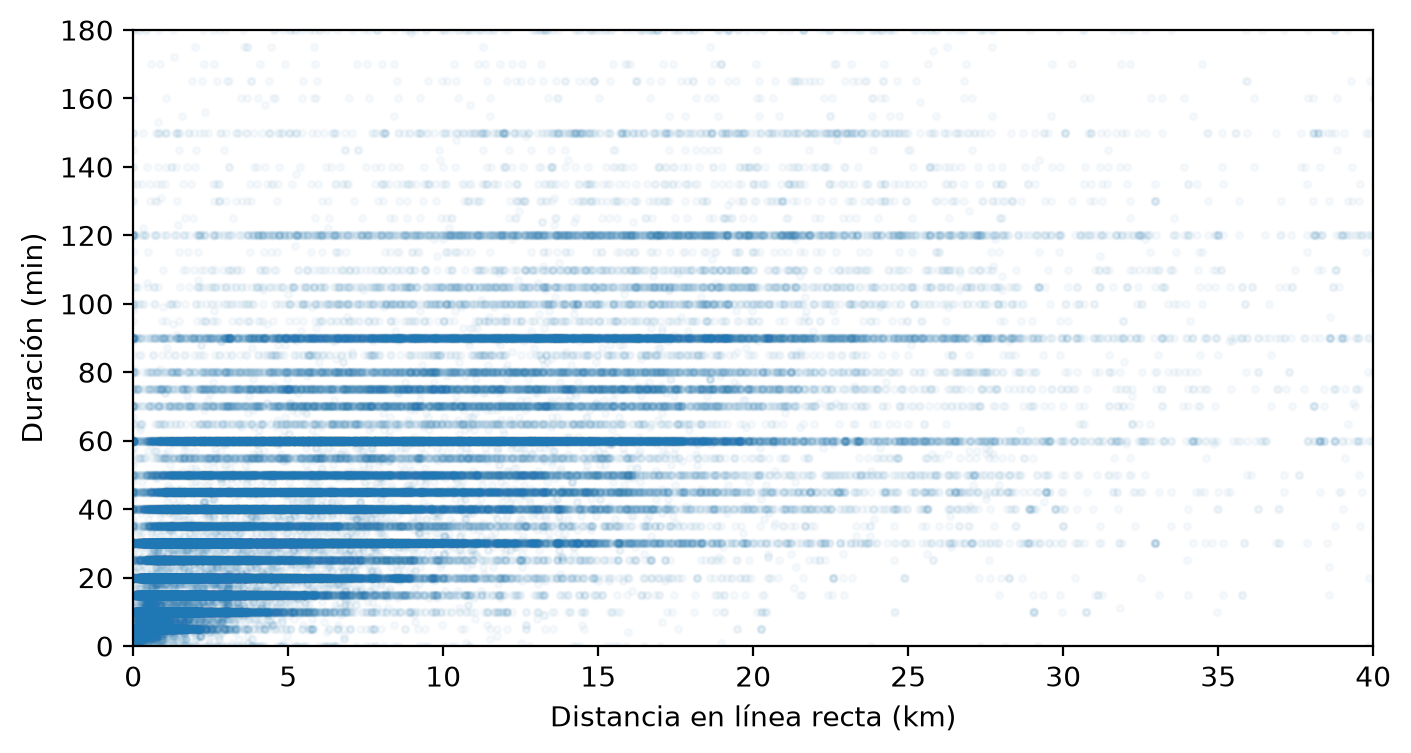

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
# alpha muy bajo: cada punto casi transparente; el color se
# acumula donde hay muchos
ax.scatter(ok["DistKm"], ok["TiempoViaje"], s=6, alpha=0.03)
ax.set_xlim(0, 40)
ax.set_ylim(0, 180)
ax.set_xlabel("Distancia en línea recta (km)")
ax.set_ylabel("Duración (min)")
plt.show()

Las franjas horizontales son los tiempos redondeados (30, 45, 60 minutos): la moda de la clase 2, ahora visible en dos dimensiones. La alternativa al alpha es `hexbin`, donde el color cuenta los viajes por celda:

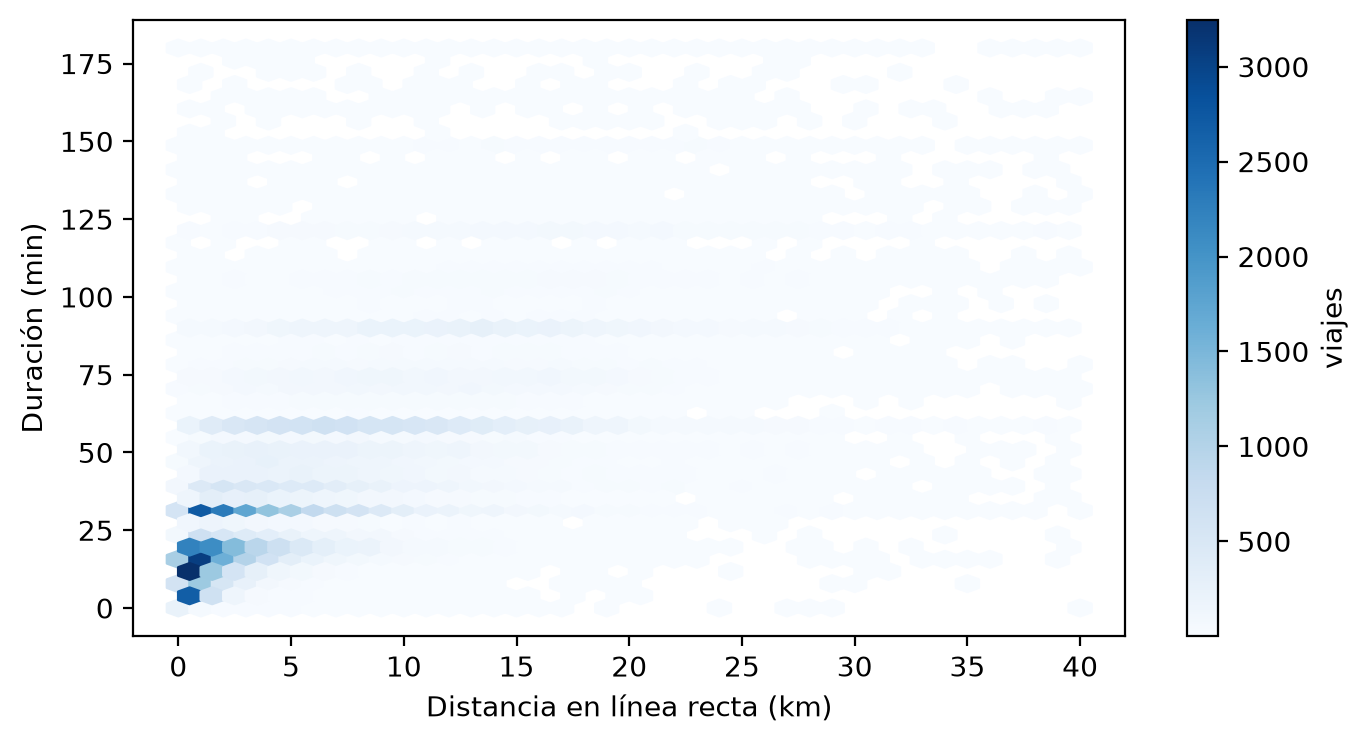

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
hb = ax.hexbin(ok["DistKm"], ok["TiempoViaje"], gridsize=40,
               cmap="Blues", mincnt=1, extent=(0, 40, 0, 180))
ax.set_xlabel("Distancia en línea recta (km)")
ax.set_ylabel("Duración (min)")
fig.colorbar(hb, label="viajes")
plt.show()

### Pearson y Spearman

¿Cuánto se asocian distancia y duración? Pearson mide la relación lineal; **Spearman** calcula el Pearson de los **rangos** (la posición de cada valor en el orden), así que resiste atípicos y captura relaciones monótonas aunque no sean rectas:

In [16]:
print("Pearson: ", round(ok["DistKm"].corr(ok["TiempoViaje"]), 2))
print("Spearman:", round(ok["DistKm"].corr(ok["TiempoViaje"], method="spearman"), 2))

Pearson:  0.54
Spearman: 0.71


0,54 contra 0,70: la diferencia delata atípicos y curvatura. Cuando Pearson y Spearman discrepan, la respuesta está en el gráfico, no en elegir un número.

Y la advertencia que acompaña a toda correlación: **correlación no es causalidad**. Con datos observacionales reportamos asociación; que dos variables se muevan juntas no dice que una cause a la otra.

## 4. Grupos y tablas de contingencia

Para dos **categóricas**, el resumen es la tabla de contingencia: cuenta las combinaciones. Veamos el modo de transporte según el sexo. El sexo está en la tabla de personas, así que primero los merges (el modo, igual que la clase pasada; el sexo, con la llave compuesta Hogar y Persona):

In [17]:
modo_por_viaje = pd.read_csv(BASE + "ViajesDifusion.csv", sep=";")
nombres_modo = pd.read_csv(BASE + "tablas_parametros/ModoDifusion.csv", sep=";")
nombres_modo = nombres_modo.rename(columns={"ModoDifusion": "NombreModo"})

viajes_modo = (viajes
    .merge(modo_por_viaje, on="Viaje")
    .merge(nombres_modo, left_on="ModoDifusion", right_on="ID")
    # La llave compuesta: la persona 1 del hogar 2 no es la del hogar 3
    .merge(personas[["Hogar", "Persona", "Sexo"]], on=["Hogar", "Persona"]))

viajes_modo["ModoAgrupado"] = viajes_modo["NombreModo"].where(
    ~viajes_modo["NombreModo"].str.startswith("Bip!"),
    "Bip! (solo o combinado)")
len(viajes_modo)

113591

In [18]:
# El sexo viene como código; el diccionario lo traduce
viajes_modo["SexoNombre"] = viajes_modo["Sexo"].map({1: "Hombre", 2: "Mujer"})

pd.crosstab(viajes_modo["SexoNombre"], viajes_modo["ModoAgrupado"])

ModoAgrupado,Auto,Bicicleta,Bip! (solo o combinado),Caminata,Otros,Taxi,Taxi Colectivo
SexoNombre,,,,,,,
Hombre,14964,2888,17073,12711,4445,598,1125
Mujer,11473,982,18704,21116,4040,1064,2408


Los conteos son difíciles de comparar porque hay más viajes de mujeres que de hombres. `normalize="index"` convierte cada fila en proporciones:

In [19]:
(pd.crosstab(viajes_modo["SexoNombre"], viajes_modo["ModoAgrupado"],
             normalize="index") * 100).round(1)

ModoAgrupado,Auto,Bicicleta,Bip! (solo o combinado),Caminata,Otros,Taxi,Taxi Colectivo
SexoNombre,,,,,,,
Hombre,27.8,5.4,31.7,23.6,8.3,1.1,2.1
Mujer,19.2,1.6,31.3,35.3,6.8,1.8,4.0


Y el cuidado de siempre: estas proporciones describen la muestra. Para hablar de la ciudad se pondera, sumando factores de expansión en vez de contar viajes (aquí, el día laboral normal):

In [20]:
lab = viajes_modo.dropna(subset=["FactorLaboralNormal", "SexoNombre"])

# pivot_table con aggfunc="sum": suma los factores de cada celda
tabla = lab.pivot_table(values="FactorLaboralNormal", index="SexoNombre",
                        columns="ModoAgrupado", aggfunc="sum")

# Cada fila dividida por su total, en porcentaje
(tabla.div(tabla.sum(axis=1), axis=0) * 100).round(1)

ModoAgrupado,Auto,Bicicleta,Bip! (solo o combinado),Caminata,Otros,Taxi,Taxi Colectivo
SexoNombre,,,,,,,
Hombre,28.4,6.0,27.9,26.6,7.7,1.2,2.1
Mujer,19.1,1.9,26.2,40.3,6.2,1.9,4.5


Ponderado, el contraste se acentúa: las mujeres caminan más (40% contra 27%) y los hombres usan más el auto (28% contra 19%) y la bicicleta (6% contra 1,9%). Un hallazgo real de género y movilidad, sacado con dos tablas y un merge.

## 5. La primera regresión

La correlación dice cuánto se asocian distancia y duración; la **regresión lineal** dibuja la recta que mejor resume esa asociación (la de mínimos cuadrados: la que deja la menor suma de errores al cuadrado). `np.polyfit` la ajusta; el 1 pide grado 1, una recta:

In [21]:
pendiente, intercepto = np.polyfit(ok["DistKm"], ok["TiempoViaje"], 1)

print("Pendiente: ", round(pendiente, 2), "minutos por km")
print("Intercepto:", round(intercepto, 1), "minutos")

Pendiente:  2.49 minutos por km
Intercepto: 25.4 minutos


Los dos números se interpretan: cada kilómetro agrega **2,5 minutos**, y un viaje "parte" costando **25 minutos** aunque la distancia sea cero (caminatas, esperas, transbordos). Ahora la recta sobre la nube:

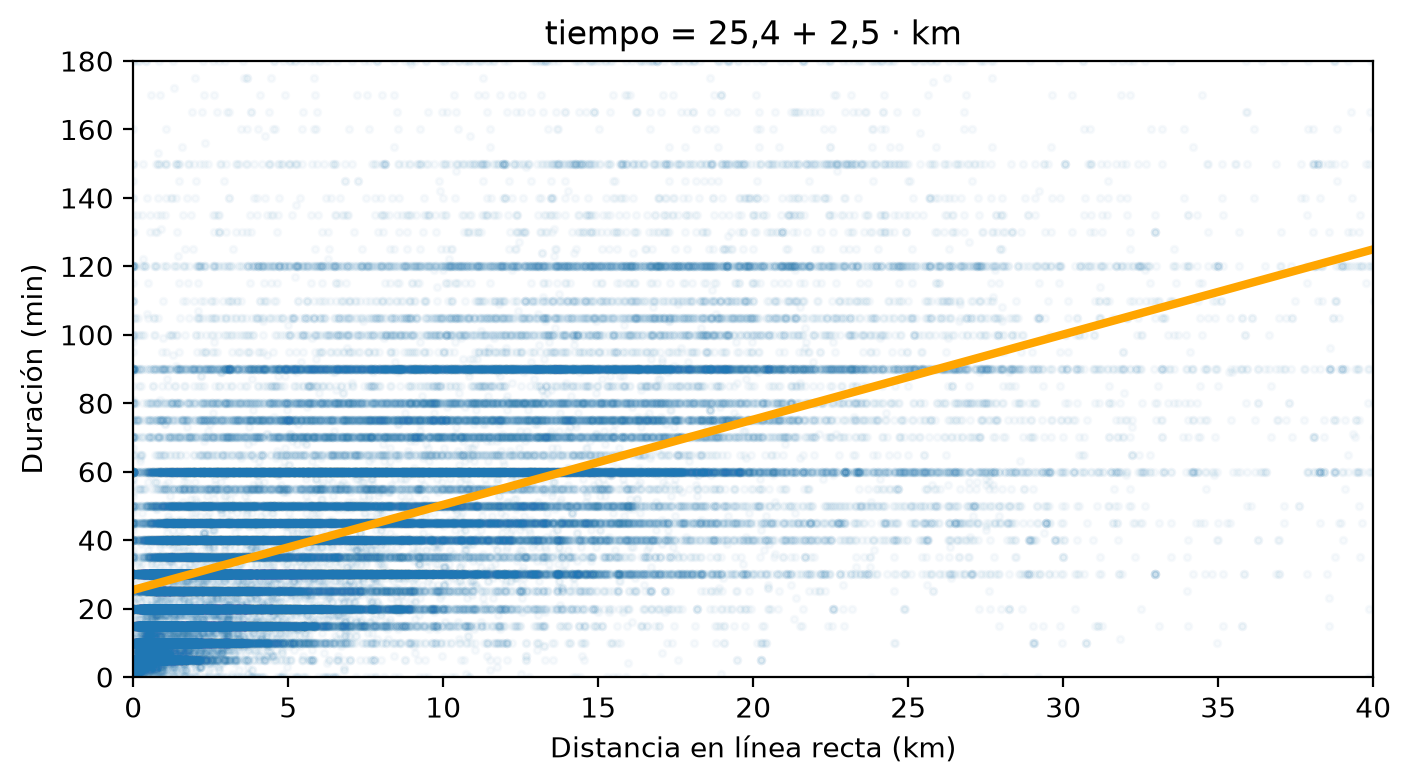

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(ok["DistKm"], ok["TiempoViaje"], s=6, alpha=0.03)

# La recta, evaluada en dos puntos del eje x
x = np.array([0, 40])
ax.plot(x, intercepto + pendiente * x, color="orange", lw=3)
ax.set_xlim(0, 40)
ax.set_ylim(0, 180)
ax.set_xlabel("Distancia en línea recta (km)")
ax.set_ylabel("Duración (min)")
ax.set_title("tiempo = 25,4 + 2,5 · km")
plt.show()

Esto es un primer contacto: en las clases 6 y 7 la regresión se profundiza (varias variables, diagnósticos y regularización).

## 6. Cuándo usar escala logarítmica

Con colas largas como el ingreso, la escala lineal aplasta el 99% de los datos contra el borde. Graficar el logaritmo reparte el espacio y la forma aparece:

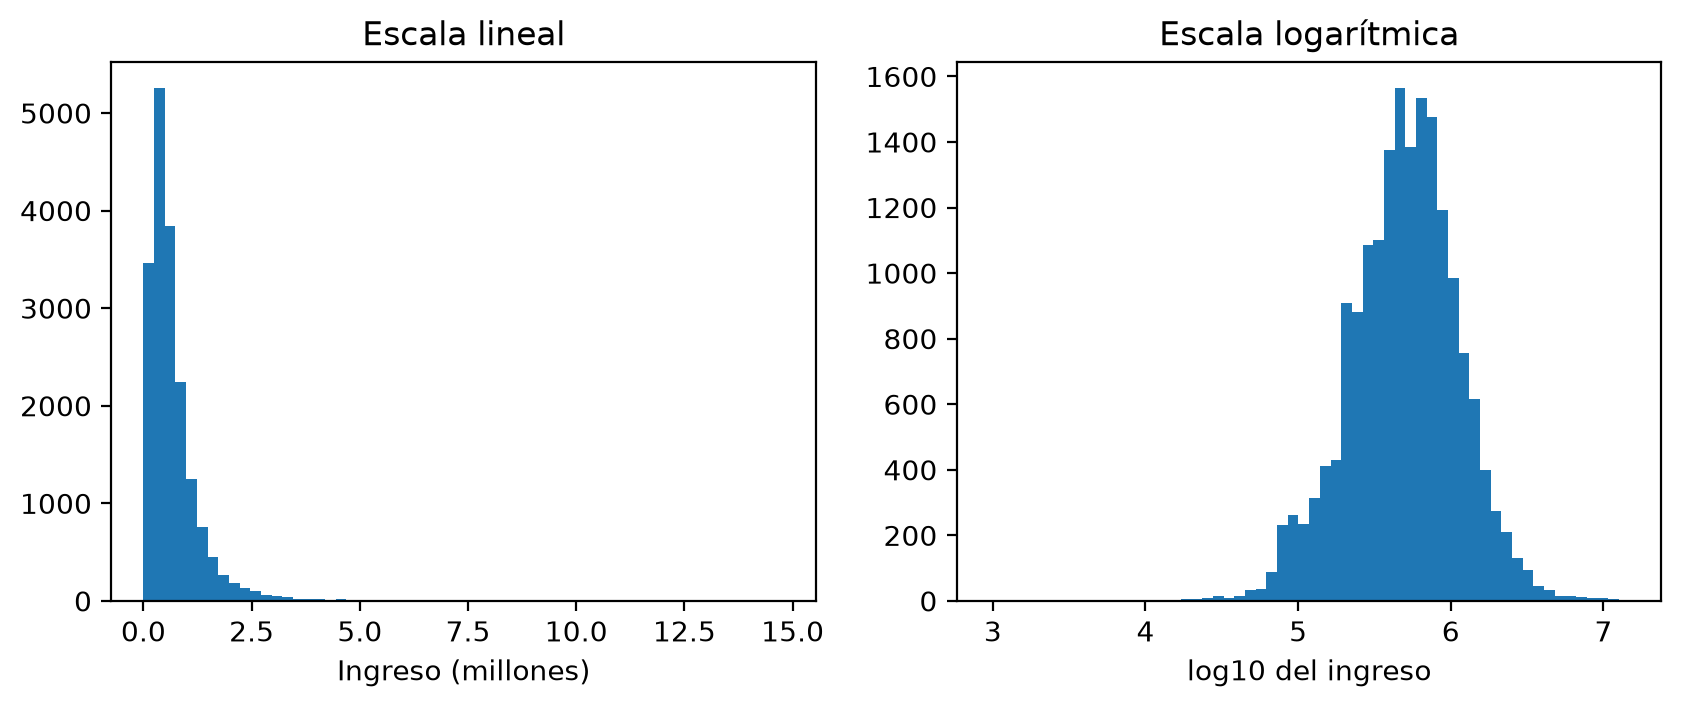

In [23]:
ingreso = hogares["IngresoHogar"].dropna()
# El logaritmo no acepta ceros
ingreso = ingreso[ingreso > 0]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(ingreso / 1e6, bins=60)
axes[0].set_title("Escala lineal")
axes[0].set_xlabel("Ingreso (millones)")
axes[1].hist(np.log10(ingreso), bins=60)
axes[1].set_title("Escala logarítmica")
axes[1].set_xlabel("log10 del ingreso")
plt.show()

En log10, un 6 es un millón de pesos y un 7, diez millones: cada paso del eje multiplica por 10.

## 7. Ejercicio (voluntario)

Con los datos de su proyecto (o con la EOD si aún no los tiene):

1. La matriz de correlación de sus variables cuantitativas. ¿Hay pares redundantes? ¿Cuáles descartaría?
2. Un scatter de las dos variables más relevantes para su pregunta, cuidando el overplotting si hay muchas filas.
3. Una tabla de contingencia o un groupby que cruce una categórica con su variable de interés.

Todo esto es material directo para el primer análisis exploratorio, que se entrega el lunes 15.

In [24]:
# Su solución


---

**Próxima clase (jueves 03-sep):** presentaciones breves de las ideas de proyecto (5 minutos por equipo, sin nota) y fundamentos de probabilidad. Recuerde: la formulación del Capstone se entrega el lunes 7 de septiembre.